<a href="https://colab.research.google.com/github/ponaalagar/tranfer_learning/blob/main/image_colorization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

from skimage import io
from skimage import data as skdata #--
from skimage.transform import resize #--
from skimage.color import rgb2lab, lab2rgb, rgb2gray, gray2rgb #--

from sklearn.model_selection import train_test_split
import tensorflow as tf

from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input

from tensorflow.keras.layers import (Input, Conv2D, UpSampling2D,
    concatenate, RepeatVector, Reshape)
from tensorflow.keras.models import Model

from tensorflow.keras.callbacks import EarlyStopping

In [2]:
DIM = 256

raw = [
    skdata.astronaut(), skdata.chelsea(), skdata.coffee(),
    skdata.colorwheel(), skdata.hubble_deep_field(),
    skdata.immunohistochemistry(), skdata.rocket(),
    skdata.retina(), skdata.skin(), skdata.cat(),
    skdata.brick(), skdata.grass(), skdata.gravel(), skdata.moon(),
]

imgs = []
for img in raw:
    if img.ndim == 2: img = gray2rgb(img)
    elif img.shape[2] == 4: img = img[:,:,:3]
    if img.dtype != np.float64: img = img / 255.0
    imgs.append(resize(img, (DIM, DIM)).astype(np.float64))


imgs = np.array(imgs)
lab  = rgb2lab(imgs)
X    = lab[:,:,:,0].reshape(-1, DIM, DIM, 1)
Y    = lab[:,:,:,1:] / 128

idx = list(range(len(imgs)))
idx_tr, idx_te = train_test_split(idx, test_size=0.3, random_state=2)
X_train, X_test = X[idx_tr], X[idx_te]
Y_train, Y_test = Y[idx_tr], Y[idx_te]
print(f'{len(imgs)} images loaded. Train: {len(X_train)}  Test: {len(X_test)}')


14 images loaded. Train: 9  Test: 5


After uploading your image (e.g., `my_custom_image.jpg`), you can load and preprocess it like this:

In [ ]:
from skimage import io

# Define the custom image path and desired dimension
custom_image_path = 'my_custom_image.jpg' # Replace with your uploaded image file name
NEW_DIM = 256 # You can change this value to control the image dimension

# Load the custom image
custom_img_raw = io.imread(custom_image_path)

# Process the custom image similar to how skdata images are processed
if custom_img_raw.ndim == 2:
    custom_img = gray2rgb(custom_img_raw)
elif custom_img_raw.shape[2] == 4:
    custom_img = custom_img_raw[:,:,:3]
else:
    custom_img = custom_img_raw

if custom_img.dtype != np.float64:
    custom_img = custom_img / 255.0

custom_img_resized = resize(custom_img, (NEW_DIM, NEW_DIM)).astype(np.float64)

# Convert to LAB color space and extract L and AB channels
custom_img_lab = rgb2lab(custom_img_resized)
X_custom = custom_img_lab[:,:,0].reshape(1, NEW_DIM, NEW_DIM, 1) # L channel
Y_custom = custom_img_lab[:,:,1:] / 128                     # AB channels

print(f'Custom image loaded and processed with dimensions: {NEW_DIM}x{NEW_DIM}')
print('X_custom shape (L channel):', X_custom.shape)
print('Y_custom shape (AB channels):', Y_custom.shape)

To use this custom image in place of one of the `skdata` images (for example, to replace the cat image if you want to test colorization on your own image), you can modify the `imgs` array or the `X_test`/`Y_test` arrays directly.

Alternatively, you can append your custom image to the existing datasets or create new test sets for it. For example, to colorize your custom image:

1.  **Generate embedding for your custom image:**
    ```python
    emb_custom = embed(X_custom)
    print('Custom image embedding:', emb_custom.shape)
    ```
2.  **Make a prediction:**
    ```python
    pred_custom = model.predict([X_custom, emb_custom]) * 128
    ```
3.  **Display the result:**
    ```python
    result_custom = np.zeros((NEW_DIM, NEW_DIM, 3))
    result_custom[:,:,0]  = X_custom[0,:,:,0]
    result_custom[:,:,1:] = pred_custom[0]

    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    fig.suptitle('Custom Image Colorization', fontsize=13, fontweight='bold')
    ax[0].imshow(X_custom[0,:,:,0], cmap='gray'); ax[0].set_title('Grayscale'); ax[0].axis('off')
    ax[1].imshow(lab2rgb(result_custom));              ax[1].set_title('Colorized'); ax[1].axis('off')
    plt.tight_layout(); plt.show()
    ```

**To control the dimension:**

In Cell `c02`, the `DIM` variable is set to 256. This variable is used to resize all images to `(DIM, DIM)`. If you wish to change the default dimension for all images loaded from `skdata`, you can modify `DIM` in Cell `c02`.

For a custom image, as shown above, you can define `NEW_DIM` to whatever size you prefer.

In [3]:
FUSE = DIM // 8   # spatial size after 3 stride-2 convolutions

vgg16 = VGG16(weights='imagenet', include_top=True)
vgg16.trainable = False

def embed(X_l):
    gs = np.array([resize(gray2rgb(x[:,:,0]), (224,224,3)) for x in X_l])
    return vgg16.predict(preprocess_input((gs*255).astype(np.float32)), verbose=0)

emb_train = embed(X_train)
emb_test  = embed(X_test)
print('Embeddings:', emb_train.shape)


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Embeddings: (9, 1000)


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

class ColorizationDataGenerator(tf.keras.utils.Sequence):

    def __init__(self, X_set, Y_set, Emb_set, batch_size, shuffle=True, augment=False):
        self.X, self.Y, self.Emb = X_set, Y_set, Emb_set
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment

        if self.augment:
            # Define ImageDataGenerator for pixel-level augmentation on L-channel.
            # Geometric augmentations (rotation, flip, shift, zoom) are generally avoided here
            # because the `Emb_set` (VGG embeddings) are pre-computed on *unaugmented* images.
            # If geometric augmentation is critical, you would need to:
            # 1. Recompute embeddings for *each augmented batch* (very slow if VGG is large).
            # 2. Pre-generate a vastly augmented dataset with corresponding embeddings.
            self.image_datagen = ImageDataGenerator(
                brightness_range=[0.8, 1.2], # Example: slightly change brightness
                channel_shift_range=0.1,    # Example: slight channel shift
                fill_mode='nearest'
            )

        self.on_epoch_end()

    def __len__(self):
        # Number of batches per epoch
        return int(np.floor(len(self.X) / self.batch_size))

    def __getitem__(self, idx):
        # Get batch indices
        indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]

        # Retrieve batch data
        X_batch_L = self.X[indices]
        Y_batch_AB = self.Y[indices]
        Emb_batch = self.Emb[indices]

        if self.augment:
            # Apply pixel-level augmentation to the L-channel batch
            # Note: For `ImageDataGenerator.apply_transform`, the input is (batch_size, H, W, C)
            # and it returns a single augmented image, not a batch. The `flow` method is for batching.
            # To augment a batch in-memory, we can iterate or use `flow` with `batch_size=len(X_batch_L)`.
            # A simpler way for pixel-level augmentations is often direct numpy operations.
            # For example, using flow on the batch itself:
            X_batch_L = self.image_datagen.flow(X_batch_L, batch_size=len(X_batch_L), shuffle=False).next()
            # Y_batch_AB (ground truth colors) are typically not augmented in the same pixel-level way
            # as the L-channel for brightness/channel shift, but would be for geometric transforms.
            # Since we avoid geometric for emb_train consistency, Y_batch_AB remains as is.

        return [X_batch_L, Emb_batch], Y_batch_AB

    def on_epoch_end(self):
        # Shuffle indices at the end of each epoch
        self.indices = np.arange(len(self.X))
        if self.shuffle:
            np.random.shuffle(self.indices)

# Create the training generator
train_generator = ColorizationDataGenerator(
    X_train, Y_train, emb_train, batch_size=2, shuffle=True, augment=True
)

# You can now use this generator to train your model
# (This will replace the model.fit call in cell c05)
# history = model.fit(
#     train_generator,
#     epochs=200,
#     callbacks=[EarlyStopping(monitor='loss', patience=10)]
# )

print("Custom Data Generator created successfully.")

Now, to use this generator for training, you would modify the `model.fit` call in cell `c05` like this:

In [ ]:
# Example of how to modify cell c05's model.fit call
# (Do NOT execute this cell, it's just to show the change)

# Assuming `train_generator` is already defined as in the previous cell.
# You would uncomment and run this in cell c05 after defining the generator.

# history = model.fit(
#     train_generator,
#     epochs=200, # Use the batch_size defined in the generator
#     callbacks=[EarlyStopping(monitor='loss', patience=10)]
# )

# Note that when using a generator, you typically don't pass `batch_size` directly to model.fit,
# as the batching is handled by the generator itself.

**Key points for your exam:**

*   **`tf.keras.utils.Sequence`**: This is recommended for complex data pipelines, custom batching, and on-the-fly processing, especially when you have multiple inputs/outputs or need custom logic that `ImageDataGenerator.flow()` doesn't directly support.
*   **`ImageDataGenerator`**: Primarily used for data augmentation (geometric and pixel-level) and efficient batching from directories.
*   **Augmentation Strategy**: When using pre-computed embeddings (like your VGG features), be cautious with geometric augmentations. Pixel-level augmentations (brightness, contrast, noise) are generally safer as they don't drastically change the spatial structure the VGG embeddings are based on.
*   **Efficiency**: Calling `embed()` (which runs VGG) inside `__getitem__` would be very slow for every batch. Pre-computing embeddings (`emb_train`) for the *static* dataset is usually more efficient for this type of model.

In [4]:
enc_in = Input(shape=(DIM, DIM, 1), name='grayscale_input')
emb_in = Input(shape=(1000,),        name='embedding_input')

# Encoder (8 Conv2D)
e = Conv2D(64,  (3,3), activation='relu', padding='same', strides=2)(enc_in)
e = Conv2D(128, (3,3), activation='relu', padding='same')(e)
e = Conv2D(128, (3,3), activation='relu', padding='same', strides=2)(e)
e = Conv2D(256, (3,3), activation='relu', padding='same')(e)
e = Conv2D(256, (3,3), activation='relu', padding='same', strides=2)(e)
e = Conv2D(512, (3,3), activation='relu', padding='same')(e)
e = Conv2D(512, (3,3), activation='relu', padding='same')(e)
e = Conv2D(256, (3,3), activation='relu', padding='same')(e)

# Fusion
f = RepeatVector(FUSE * FUSE)(emb_in)
f = Reshape([FUSE, FUSE, 1000])(f)
f = concatenate([e, f], axis=3)
f = Conv2D(256, (1,1), activation='relu', padding='same')(f)

# Decoder (5 Conv2D)
d = Conv2D(128, (3,3), activation='relu', padding='same')(f)
d = UpSampling2D((2,2))(d)
d = Conv2D(64,  (3,3), activation='relu', padding='same')(d)
d = UpSampling2D((2,2))(d)
d = Conv2D(32,  (3,3), activation='relu', padding='same')(d)
d = Conv2D(16,  (3,3), activation='relu', padding='same')(d)
d = Conv2D(2,   (3,3), activation='tanh', padding='same')(d)
d = UpSampling2D((2,2))(d)

model = Model(inputs=[enc_in, emb_in], outputs=d)
model.compile(optimizer='rmsprop', loss='mse')
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ grayscale_input     │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        640 │ grayscale_input[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     73,856 │ conv2d[0][0]      │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_1[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    295,168 │ conv2d_2[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_3[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ conv2d_4[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_input     │ (None, 1000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_5[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 1024,      │          0 │ embedding_input[… │
│ (RepeatVector)      │ 1000)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  1,179,904 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 32, 32,    │          0 │ repeat_vector[0]… │
│                     │ 1000)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_7[0][0],   │
│ (Concatenate)       │ 1256)             │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │    321,792 │ concatenate[0][0] │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │    295,040 │ conv2d_8[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_9[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 64, 64,    │     73,792 │ up_sampling2d[0]

 Total params: 6,541,202 (24.95 MB)

 Trainable params: 6,541,202 (24.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - loss: 0.6212
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - loss: 0.0601
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - loss: 0.0308
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - loss: 0.0293
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - loss: 0.0240
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - loss: 0.0480
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - loss: 0.0241
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - loss: 0.0222
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - loss: 0.0224
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - loss: 0.0235
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - loss: 0.0237
Epoch 12/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - loss: 0.0238
Epoch 13/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - loss: 0.0223
Epoch 14/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - loss: 0.0240
Epoch 15/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - loss: 0.0220
Epoch 16/200
5/5 ━━━━━━━━━━━━━━━━━

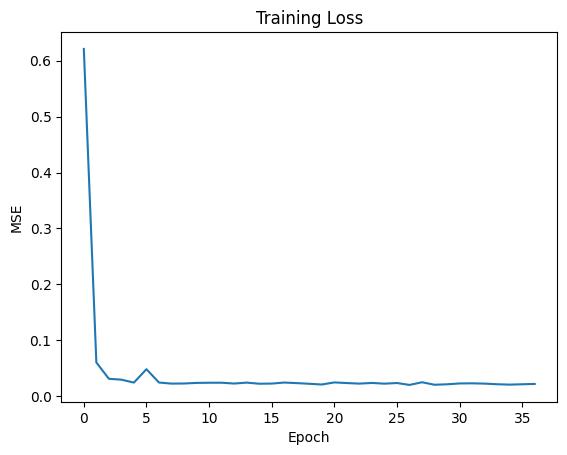

In [5]:
history = model.fit(
    [X_train, emb_train], Y_train,
    epochs=200, batch_size=2,
    callbacks=[EarlyStopping(monitor='loss', patience=10)]
)
plt.plot(history.history['loss'])
plt.title('Training Loss'); plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


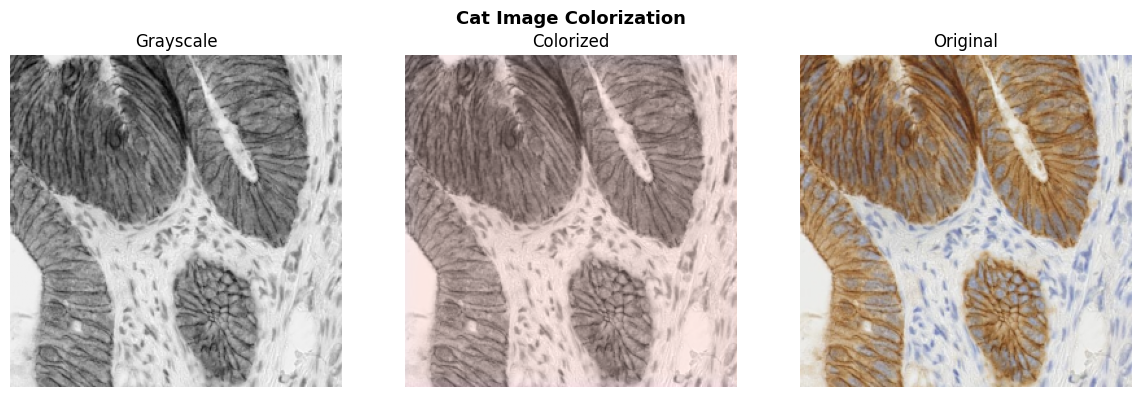

In [10]:
pred = model.predict([X_test, emb_test]) * 128

CAT_IDX = 5 # cat is at position 9 in the raw list
if CAT_IDX in idx_te:
    i = list(idx_te).index(CAT_IDX)
    result = np.zeros((DIM, DIM, 3))
    result[:,:,0]  = X_test[i,:,:,0]
    result[:,:,1:] = pred[i]
    orig = np.zeros((DIM, DIM, 3))
    orig[:,:,0]    = X_test[i,:,:,0]
    orig[:,:,1:]   = Y_test[i] * 128
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle('Cat Image Colorization', fontsize=13, fontweight='bold')
    ax[0].imshow(X_test[i,:,:,0], cmap='gray'); ax[0].set_title('Grayscale'); ax[0].axis('off')
    ax[1].imshow(lab2rgb(result));              ax[1].set_title('Colorized'); ax[1].axis('off')
    ax[2].imshow(lab2rgb(orig));                ax[2].set_title('Original');  ax[2].axis('off')
    plt.tight_layout(); plt.show()
else:
    print('Cat is in training set. Change random_state in Cell 2 to move it to test set.')
